In [1]:
import numpy as np
import pandas as pd
import matplotlib.pylab as plt
import seaborn as sns

In [3]:
vendor = pd.read_csv("../Inventory/vendor_invoice.csv")

print("Vendor Invoice:")
print(vendor.head())
print(vendor.columns)

Vendor Invoice:
   VendorNumber                   VendorName InvoiceDate  PONumber  \
0           105  ALTAMAR BRANDS LLC           2024-01-04      8124   
1          4466  AMERICAN VINTAGE BEVERAGE    2024-01-07      8137   
2           388  ATLANTIC IMPORTING COMPANY   2024-01-09      8169   
3           480  BACARDI USA INC              2024-01-12      8106   
4           516  BANFI PRODUCTS CORP          2024-01-07      8170   

       PODate     PayDate  Quantity    Dollars  Freight Approval  
0  2023-12-21  2024-02-16         6     214.26     3.47      NaN  
1  2023-12-22  2024-02-21        15     140.55     8.57      NaN  
2  2023-12-24  2024-02-16         5     106.60     4.61      NaN  
3  2023-12-20  2024-02-05     10100  137483.78  2935.20      NaN  
4  2023-12-24  2024-02-12      1935   15527.25   429.20      NaN  
Index(['VendorNumber', 'VendorName', 'InvoiceDate', 'PONumber', 'PODate',
       'PayDate', 'Quantity', 'Dollars', 'Freight', 'Approval'],
      dtype='str')


In [4]:
purchases = pd.read_csv("../Inventory/purchases.csv")

print("\nPurchases:")
print(purchases.head())
print(purchases.columns)


Purchases:
           InventoryId  Store  Brand                   Description   Size  \
0    69_MOUNTMEND_8412     69   8412     Tequila Ocho Plata Fresno  750mL   
1     30_CULCHETH_5255     30   5255  TGI Fridays Ultimte Mudslide  1.75L   
2    34_PITMERDEN_5215     34   5215  TGI Fridays Long Island Iced  1.75L   
3  1_HARDERSFIELD_5255      1   5255  TGI Fridays Ultimte Mudslide  1.75L   
4    76_DONCASTER_2034     76   2034     Glendalough Double Barrel  750mL   

   VendorNumber                   VendorName  PONumber      PODate  \
0           105  ALTAMAR BRANDS LLC               8124  2023-12-21   
1          4466  AMERICAN VINTAGE BEVERAGE        8137  2023-12-22   
2          4466  AMERICAN VINTAGE BEVERAGE        8137  2023-12-22   
3          4466  AMERICAN VINTAGE BEVERAGE        8137  2023-12-22   
4           388  ATLANTIC IMPORTING COMPANY       8169  2023-12-24   

  ReceivingDate InvoiceDate     PayDate  PurchasePrice  Quantity  Dollars  \
0    2024-01-02  2024-01-04

In [5]:
prices = pd.read_csv("../Inventory/purchase_prices.csv")

print("\nPurchase Prices:")
print(prices.head())
print(prices.columns)


Purchase Prices:
   Brand                  Description  Price   Size Volume  Classification  \
0     58  Gekkeikan Black & Gold Sake  12.99  750mL    750               1   
1     62     Herradura Silver Tequila  36.99  750mL    750               1   
2     63   Herradura Reposado Tequila  38.99  750mL    750               1   
3     72         No. 3 London Dry Gin  34.99  750mL    750               1   
4     75    Three Olives Tomato Vodka  14.99  750mL    750               1   

   PurchasePrice  VendorNumber                   VendorName  
0           9.28          8320  SHAW ROSS INT L IMP LTD      
1          28.67          1128  BROWN-FORMAN CORP            
2          30.46          1128  BROWN-FORMAN CORP            
3          26.11          9165  ULTRA BEVERAGE COMPANY LLP   
4          10.94          7245  PROXIMO SPIRITS INC.         
Index(['Brand', 'Description', 'Price', 'Size', 'Volume', 'Classification',
       'PurchasePrice', 'VendorNumber', 'VendorName'],
      dtyp

In [24]:
# Convert dates
purchases['PODate'] = pd.to_datetime(purchases['PODate'])
purchases['ReceivingDate'] = pd.to_datetime(purchases['ReceivingDate'])

# Create delay
purchases['receiving_delay'] = (purchases['ReceivingDate'] - purchases['PODate']).dt.days

# Group by PONumber
agg_data = purchases.groupby('PONumber').agg({
    'Brand': 'nunique',
    'Quantity': 'sum',
    'Dollars': 'sum',
    'receiving_delay': 'mean'
}).reset_index()

# Rename columns
agg_data.columns = [
    'PONumber',
    'total_brands',
    'total_item_quantity',
    'total_item_dollars',
    'avg_receiving_delay'
]

# Preview
agg_data.head()

,PONumber,total_brands,total_item_quantity,total_item_dollars,avg_receiving_delay
0,8106,81,10100,137483.78,12.614130
1,8107,2,24,348.72,12.500000
2,8108,165,8466,60281.13,12.632479
3,8109,23,2246,14298.09,12.626866
4,8110,183,8086,56493.23,12.695271


In [25]:
agg_data.describe()

,PONumber,total_brands,total_item_quantity,total_item_dollars,avg_receiving_delay
count,5543.000000,5543.000000,5543.000000,5.543000e+03,5543.000000
mean,10889.419087,41.312466,6058.880931,5.807338e+04,7.671541
std,1600.859969,76.940674,14453.338164,1.402340e+05,1.824496
min,8106.000000,1.000000,1.000000,4.140000e+00,3.000000
25%,9503.500000,3.000000,83.000000,9.678100e+02,6.129178
50%,10890.000000,7.000000,423.000000,4.765450e+03,7.744898
75%,12275.500000,46.000000,5100.500000,4.458718e+04,9.083804
max,13661.000000,807.000000,141660.000000,1.660436e+06,13.000000


In [26]:
# Convert dates
vendor['PODate'] = pd.to_datetime(vendor['PODate'])
vendor['InvoiceDate'] = pd.to_datetime(vendor['InvoiceDate'])
vendor['PayDate'] = pd.to_datetime(vendor['PayDate'])

# Create new features
vendor['days_po_to_invoice'] = (vendor['InvoiceDate'] - vendor['PODate']).dt.days
vendor['days_to_pay'] = (vendor['PayDate'] - vendor['InvoiceDate']).dt.days

# Rename (optional for clarity)
vendor['invoice_quantity'] = vendor['Quantity']
vendor['invoice_dollars'] = vendor['Dollars']

# Preview
vendor.head()

,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval,days_po_to_invoice,days_to_pay,invoice_quantity,invoice_dollars
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,NaN,14,43,6,214.26
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,NaN,16,45,15,140.55
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,NaN,16,38,5,106.60
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,NaN,23,24,10100,137483.78
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,NaN,14,36,1935,15527.25


In [27]:
vendor[['days_po_to_invoice', 'days_to_pay']].describe()

,days_po_to_invoice,days_to_pay
count,5543.000000,5543.000000
mean,16.424499,35.468519
std,3.127282,5.842178
min,9.000000,23.000000
25%,14.000000,31.000000
50%,16.000000,35.000000
75%,19.000000,40.000000
max,23.000000,48.000000


In [28]:
df = pd.merge(
    vendor,
    agg_data,
    on='PONumber',
    how='left'
)

# Preview
df.head()

,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval,days_po_to_invoice,days_to_pay,invoice_quantity,invoice_dollars,total_brands,total_item_quantity,total_item_dollars,avg_receiving_delay
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,NaN,14,43,6,214.26,1,6,214.26,12.000000
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,NaN,16,45,15,140.55,2,15,140.55,10.333333
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,NaN,16,38,5,106.60,1,5,106.60,9.000000
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,NaN,23,24,10100,137483.78,81,10100,137483.78,12.614130
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,NaN,14,36,1935,15527.25,29,1935,15527.25,8.752809


In [29]:
df.isnull().sum()

VendorNumber              0
VendorName                0
InvoiceDate               0
PONumber                  0
PODate                    0
PayDate                   0
Quantity                  0
Dollars                   0
Freight                   0
Approval               5169
days_po_to_invoice        0
days_to_pay               0
invoice_quantity          0
invoice_dollars           0
total_brands              0
total_item_quantity       0
total_item_dollars        0
avg_receiving_delay       0
dtype: int64

In [30]:
df.dtypes

VendorNumber                    int64
VendorName                        str
InvoiceDate            datetime64[us]
PONumber                        int64
PODate                 datetime64[us]
PayDate                datetime64[us]
Quantity                        int64
Dollars                       float64
Freight                       float64
Approval                          str
days_po_to_invoice              int64
days_to_pay                     int64
invoice_quantity                int64
invoice_dollars               float64
total_brands                    int64
total_item_quantity             int64
total_item_dollars            float64
avg_receiving_delay           float64
dtype: object

In [31]:
def create_invoice_risk_label(row):

    # Condition 1: Invoice total mismatch with item-level total
    if abs(row["invoice_dollars"] - row["total_item_dollars"]) > 5:
        return 1

    # Condition 2: Abnormaly High receiving delay
    if row["avg_receiving_delay"] > 10:
        return 1

    return 0


df["flag_invoice"] = df.apply(create_invoice_risk_label, axis=1)
df["flag_invoice"].value_counts()

flag_invoice
0    3693
1    1850
Name: count, dtype: int64

“Since labeled risk data was not available, I engineered a proxy target variable using business rules such as invoice mismatch and delivery delays, enabling supervised learning.”

<Axes: xlabel='flag_invoice'>

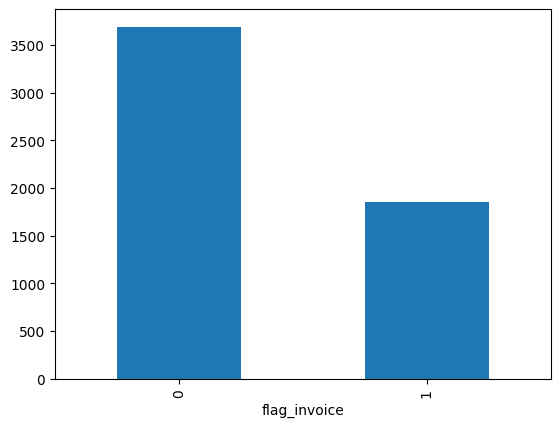

In [32]:
df['flag_invoice'].value_counts().plot(kind = 'bar')

In [40]:
df.corr(numeric_only=True)

,VendorNumber,PONumber,Quantity,Dollars,Freight,days_po_to_invoice,days_to_pay,invoice_quantity,invoice_dollars,total_brands,total_item_quantity,total_item_dollars,avg_receiving_delay,flag_invoice
VendorNumber,1.000000,0.014151,-0.168329,-0.163386,-0.163493,0.017257,-0.028856,-0.168329,-0.163386,-0.137312,-0.119220,-0.115068,0.018223,0.016953
PONumber,0.014151,1.000000,0.049230,0.058917,0.043617,-0.002234,0.012558,0.049230,0.058917,0.013423,0.049442,0.059221,-0.042362,0.564946
Quantity,-0.168329,0.049230,1.000000,0.963831,0.946550,0.000526,0.022284,1.000000,0.963831,0.566394,0.706117,0.668171,0.000519,0.032783
Dollars,-0.163386,0.058917,0.963831,1.000000,0.985141,0.001610,0.025661,0.963831,1.000000,0.536952,0.667666,0.679537,0.004694,0.037994
Freight,-0.163493,0.043617,0.946550,0.985141,1.000000,0.003265,0.025513,0.946550,0.985141,0.536381,0.656616,0.670768,0.015645,0.037759
days_po_to_invoice,0.017257,-0.002234,0.000526,0.001610,0.003265,1.000000,-0.370432,0.000526,0.001610,0.009519,0.005543,0.007931,0.515538,0.183115
days_to_pay,-0.028856,0.012558,0.022284,0.025661,0.025513,-0.370432,1.000000,0.022284,0.025661,0.020336,0.016203,0.015610,-0.029403,-0.005289
invoice_quantity,-0.168329,0.049230,1.000000,0.963831,0.946550,0.000526,0.022284,1.000000,0.963831,0.566394,0.706117,0.668171,0.000519,0.032783
invoice_dollars,-0.163386,0.058917,0.963831,1.000000,0.985141,0.001610,0.025661,0.963831,1.000000,0.536952,0.667666,0.679537,0.004694,0.037994
total_brands,-0.137312,0.013423,0.566394,0.536952,0.536381,0.009519,0.020336,0.566394,0.536952,1.000000,0.783825,0.753092,0.000496,0.008961


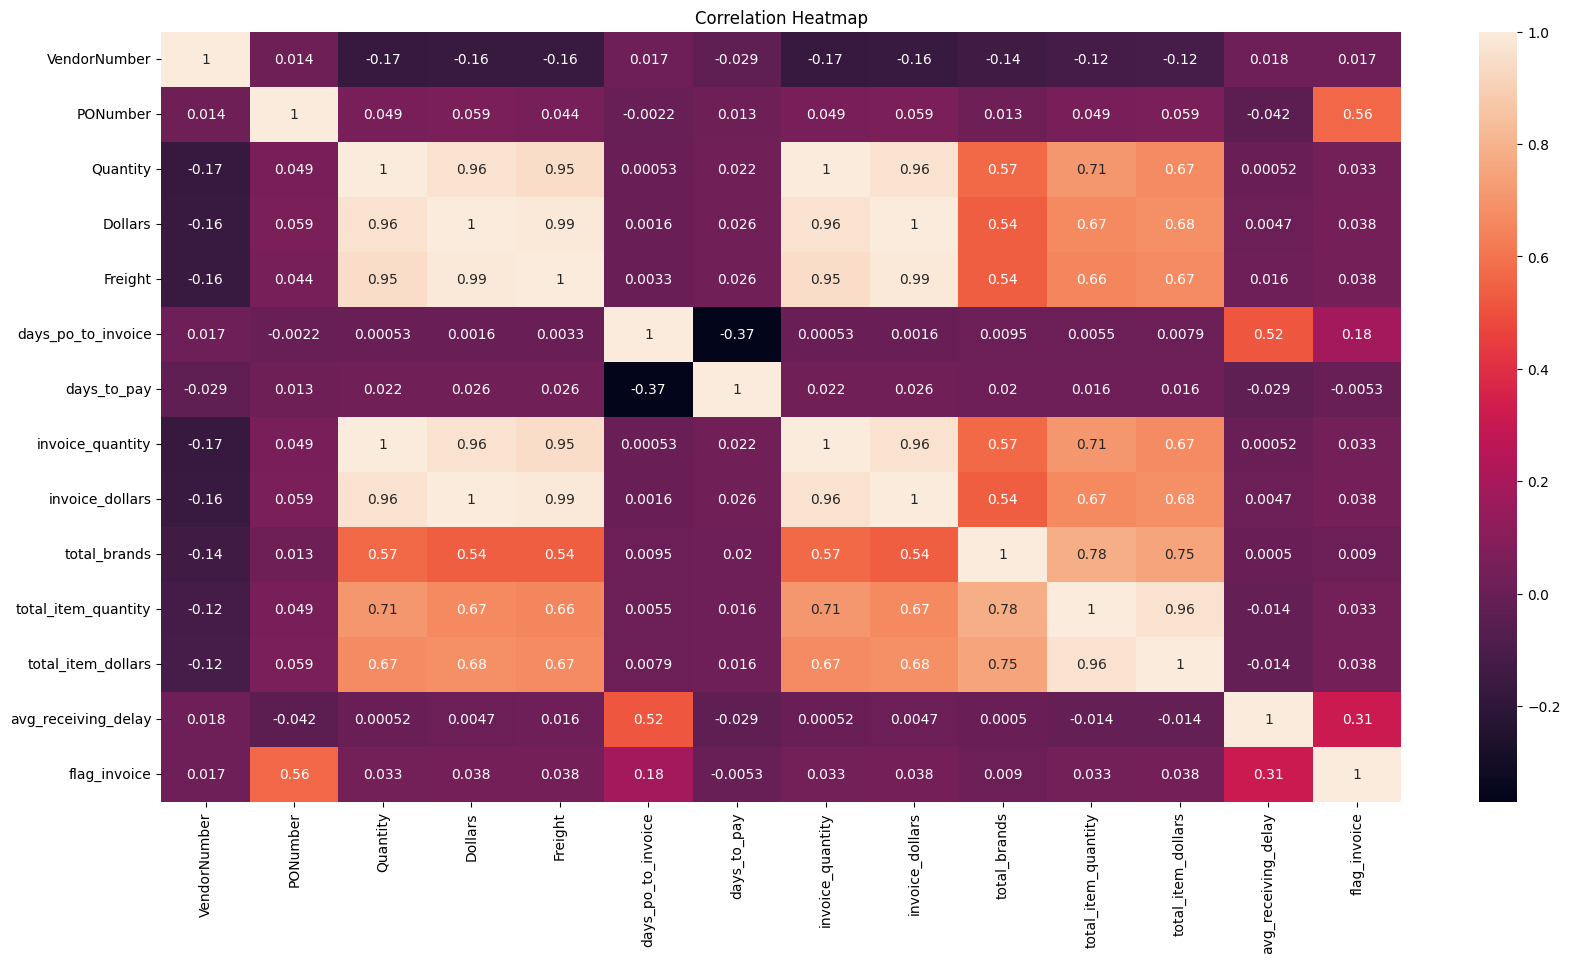

In [75]:
plt.figure(figsize=(20,10))
sns.heatmap(df.select_dtypes(include=['number']).corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

“Using statistical hypothesis testing (t-test) to identify features that significantly differentiate between risky and normal invoices.”

In [76]:
flagged = df[df['flag_invoice'] == 1]
normal = df[df['flag_invoice'] == 0]

In [77]:
significant_features = [] 
non_significant_features = [] 
results = [] 

In [78]:
metrics = ['invoice_quantity', 'invoice_dollars', 'Freight', 
           'days_po_to_invoice', 'days_to_pay', 'total_brands', 
           'total_item_quantity', 'total_item_dollars', 'avg_receiving_delay']

In [79]:
from scipy.stats import ttest_ind

for metric in metrics:

    flagged_mean = flagged[metric].mean()
    normal_mean = normal[metric].mean()

    t_stat, p_value = ttest_ind(
        flagged[metric].dropna(),
        normal[metric].dropna(),
        equal_var=False
    )

    if p_value < 0.05:
        significant_features.append(metric)
    else:
        non_significant_features.append(metric)

    results.append({
        "metric": metric,
        "flagged_mean": round(flagged_mean, 2),
        "normal_mean": round(normal_mean, 2),
        "p_value": round(p_value, 3)
    })

In [80]:
non_significant_features

['days_to_pay', 'total_brands']

In [81]:
significant_features

['invoice_quantity',
 'invoice_dollars',
 'Freight',
 'days_po_to_invoice',
 'total_item_quantity',
 'total_item_dollars',
 'avg_receiving_delay']

In [122]:
X = df[['invoice_quantity', 'invoice_dollars', 'Freight', 'total_brands',
        'days_po_to_invoice', 'total_item_quantity','total_item_dollars','avg_receiving_delay']]
y = df['flag_invoice']

In [123]:
X.describe().round()

,invoice_quantity,invoice_dollars,Freight,total_brands,days_po_to_invoice,total_item_quantity,total_item_dollars,avg_receiving_delay
count,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0
mean,6059.0,58073.0,296.0,41.0,16.0,6059.0,58073.0,8.0
std,14453.0,140234.0,714.0,77.0,3.0,14453.0,140234.0,2.0
min,1.0,4.0,0.0,1.0,9.0,1.0,4.0,3.0
25%,83.0,968.0,5.0,3.0,14.0,83.0,968.0,6.0
50%,423.0,4765.0,25.0,7.0,16.0,423.0,4765.0,8.0
75%,5100.0,44587.0,230.0,46.0,19.0,5100.0,44587.0,9.0
max,141660.0,1660436.0,8468.0,807.0,23.0,141660.0,1660436.0,13.0


In [124]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [125]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [126]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [127]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(max_depth=5)
dt.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [128]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(max_depth=6)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [129]:
y_pred_lr = lr.predict(X_test_scaled)
y_pred_dt = dt.predict(X_test)
y_pred_rf = rf.predict(X_test)

In [130]:
from sklearn.metrics import accuracy_score, classification_report

print("Logistic Regression")
print(accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

print("\nDecision Tree")
print(accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

print("\nRandom Forest")
print(accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Logistic Regression
0.739404869251578
              precision    recall  f1-score   support

           0       0.74      0.93      0.82       725
           1       0.73      0.39      0.51       384

    accuracy                           0.74      1109
   macro avg       0.74      0.66      0.67      1109
weighted avg       0.74      0.74      0.71      1109


Decision Tree
0.8548241659152389
              precision    recall  f1-score   support

           0       0.82      1.00      0.90       725
           1       1.00      0.58      0.73       384

    accuracy                           0.85      1109
   macro avg       0.91      0.79      0.82      1109
weighted avg       0.88      0.85      0.84      1109


Random Forest
0.8440036068530208
              precision    recall  f1-score   support

           0       0.81      1.00      0.89       725
           1       1.00      0.55      0.71       384

    accuracy                           0.84      1109
   macro avg       0.9

“Both Decision Tree and Random Forest performed quite similar. Since the performance difference was negligible, I selected Decision Tree due to its simplicity and interpretability.”

In [148]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, f1_score

# Define model
dt = DecisionTreeClassifier(max_depth=5, random_state=42)

# Parameter grid
param_grid = {
    "max_depth": [None, 4, 5, 6, 8],
    "min_samples_split": [2, 3, 5],
    "min_samples_leaf": [1, 2, 5],
    "criterion": ['gini', 'entropy']
}

# F1 scorer
scorer = make_scorer(f1_score)

# GridSearch
grid = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    scoring=scorer,
    cv=5,
    verbose=2,
    n_jobs=-1
)

# Fit
grid.fit(X_train, y_train)
best_dt = grid.best_estimator_

print("Best Parameters:", grid.best_params_)

from sklearn.metrics import classification_report, accuracy_score

y_pred_best = best_dt.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best))

Fitting 5 folds for each of 90 candidates, totalling 450 fits
Best Parameters: {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2}
Accuracy: 0.9422903516681695
              precision    recall  f1-score   support

           0       0.94      0.98      0.96       725
           1       0.95      0.88      0.91       384

    accuracy                           0.94      1109
   macro avg       0.94      0.93      0.94      1109
weighted avg       0.94      0.94      0.94      1109



“After initial model training, I applied GridSearchCV to optimize hyperparameters using F1-score due to class imbalance. This significantly improved model accuracy from 85% to 94%, with strong precision and recall for both classes.”